In [2]:
# Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_forecasting.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
# Data Understanding
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
# data cleaning 
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True,errors='coerce' )

# Create new features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()

In [8]:
df['Order Date'].isna().sum()

np.int64(0)

In [9]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['Month_Name'] = pd.Categorical(
    df['Month_Name'],
    categories=month_order,
    ordered=True
)

In [14]:
# Sales Overview
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = df['Sales'].mean()

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))

Total Sales: 2261536.78
Total Orders: 4922
Average Order Value: 230.77


C:\Users\Dell\AppData\Local\Temp\ipykernel_12068\715787249.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('Month_Name')['Sales'].sum().reindex([


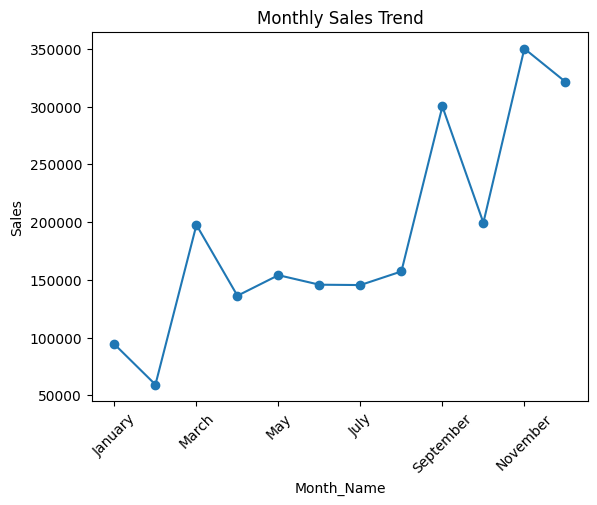

In [15]:
# Monthly Sales Trend
monthly_sales = df.groupby('Month_Name')['Sales'].sum().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure()
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

<Axes: title={'center': 'Monthly Sales Trend'}, xlabel='Month'>

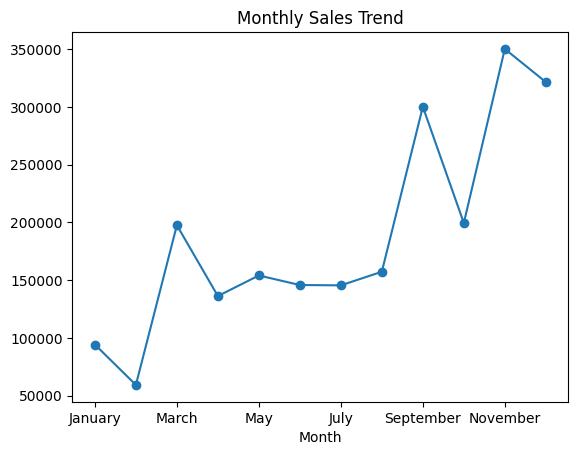

In [19]:
# Monthly Sales Trend
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Month'] = df['Order Date'].dt.month_name()

monthly_sales = df.groupby('Month')['Sales'].sum().reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

monthly_sales.plot(kind='line', marker='o', title='Monthly Sales Trend')


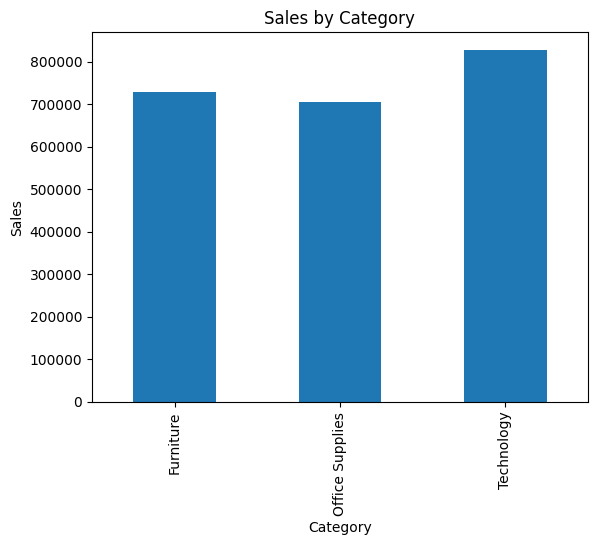

In [16]:
#Category Analysis
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

In [18]:
#Sales by Category
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sales_by_category


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [20]:
# Top 10 Products
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [21]:
df.to_csv("clean_sales_data.csv", index=False)